# Notebook 02 — Fraud MobileNetV2 Training

**Task ID:** ML-001  
**Owner:** Member 2 / Antigravity  
**Date:** 2026-09-20  
**Experiment ID:** FRAUD-MNV2-001  
**Dataset version:** Vinay Jose Car Damage v1 (8,079 images)  
**Manifests:** notebooks/data/manifests/fraud_train.csv, _val.csv, _test.csv  
**Environment:** Local CPU

## Purpose
Train a MobileNetV2 visual fraud-risk classifier on the frozen Phase 1 manifests.
The model learns to distinguish suspicious images from genuine ones.

**Scientific disclaimer:** This model outputs a *visual fraud-risk probability*.
A high score means suspicious image characteristics relative to training data.
It does NOT confirm insurance fraud and must not be used to auto-reject claims.

## Hypothesis
A fine-tuned MobileNetV2 can learn visual signals (watermarks, resolution
differences, editing artefacts) that distinguish suspicious images from genuine
car damage photographs, achieving PR-AUC well above the naive baseline.

In [5]:
# Cell 1: Imports, fixed seed, and reproducibility
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, WeightedRandomSampler

# --- Universal Repository Root Sync (Colab & Local) ---
if 'google.colab' in sys.modules or os.path.exists('/content'):
    REPO_ROOT = Path('/content/NPN-Car-Insurance')
    if REPO_ROOT.exists():
        os.chdir(str(REPO_ROOT))
else:
    current = Path.cwd().resolve()
    REPO_ROOT = current
    for parent in [current, *current.parents]:
        if (parent / '.git').exists() or (parent / 'ml').exists():
            REPO_ROOT = parent
            os.chdir(str(parent))
            break

ml_src = str(REPO_ROOT / 'ml' / 'src')
if ml_src not in sys.path:
    sys.path.insert(0, ml_src)

print(f"✅ Repository root locked to: {REPO_ROOT}")

from claimvision_ml.fraud import (
    FraudDataset,
    build_fraud_model,
    export_onnx,
    get_class_weights,
    get_transforms,
    save_preprocessing_config,
)

# Fixed seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


✅ Repository root locked to: /content/NPN-Car-Insurance
Device: cuda


In [6]:
# Cell 2: Library versions
import importlib

libs = ["torch", "torchvision", "PIL", "numpy", "pandas", "sklearn", "albumentations"]
rows = []
for lib in libs:
    try:
        mod = importlib.import_module(lib if lib != "PIL" else "PIL")
        ver = getattr(mod, "__version__", "n/a")
    except ImportError:
        ver = "NOT INSTALLED"
    rows.append({"Library": lib, "Version": ver})

pd.DataFrame(rows).set_index("Library")

,Version
Library,
torch,2.11.0+cu128
torchvision,0.26.0+cu128
PIL,11.3.0
numpy,2.1.3
pandas,2.2.3
sklearn,1.6.1
albumentations,2.0.8


In [7]:
# Cell 3: Paths and configuration (multi-candidate search for maximum compatibility)
manifest_candidates = [
    REPO_ROOT / 'data' / 'manifests',
    REPO_ROOT / 'notebooks' / 'data' / 'manifests',
    Path('data/manifests').resolve(),
    Path('notebooks/data/manifests').resolve(),
    Path('/content/NPN-Car-Insurance/data/manifests'),
    Path('/content/NPN-Car-Insurance/notebooks/data/manifests'),
]

MANIFEST_DIR = None
for candidate in manifest_candidates:
    if (candidate / 'fraud_train.csv').exists():
        MANIFEST_DIR = candidate
        break

if MANIFEST_DIR is None:
    MANIFEST_DIR = REPO_ROOT / 'data' / 'manifests'

ARTIFACT_DIR = REPO_ROOT / 'ml' / 'artifacts' / 'fraud'
RESULTS_DIR  = REPO_ROOT / 'ml' / 'results' / 'fraud'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = MANIFEST_DIR / 'fraud_train.csv'
VAL_CSV   = MANIFEST_DIR / 'fraud_val.csv'
TEST_CSV  = MANIFEST_DIR / 'fraud_test.csv'

CHECKPOINT_PATH = ARTIFACT_DIR / 'fraud_mnv2_v1.pt'
ONNX_PATH       = ARTIFACT_DIR / 'fraud_mnv2_v1.onnx'

# Training hyperparameters
BATCH_SIZE      = 16
STAGE_A_EPOCHS  = 10
STAGE_B_EPOCHS  = 20
STAGE_A_LR      = 1e-3
STAGE_B_LR      = 1e-5
DROPOUT         = 0.3
PATIENCE        = 5   # early stopping patience on val PR-AUC

print(f"Train: {TRAIN_CSV}")
print(f"Val:   {VAL_CSV}")
print(f"Test:  {TEST_CSV}")
print(f"Artifacts -> {ARTIFACT_DIR}")


Train: /content/NPN-Car-Insurance/data/manifests/fraud_train.csv
Val:   /content/NPN-Car-Insurance/data/manifests/fraud_val.csv
Test:  /content/NPN-Car-Insurance/data/manifests/fraud_test.csv
Artifacts -> /content/NPN-Car-Insurance/ml/artifacts/fraud


In [8]:
# Cell 4: Load manifests and verify split counts
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("=== Split counts ===")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    gen  = (df["label"] == 0).sum()
    susp = (df["label"] == 1).sum()
    print(f"  {name:5s}: {len(df):5d} total | genuine={gen} | suspicious={susp} | ratio={gen/max(susp,1):.1f}:1")

pos_weight = get_class_weights(TRAIN_CSV)
print(f"\nBCEWithLogitsLoss pos_weight (genuine/suspicious): {pos_weight.item():.2f}")

=== Split counts ===
  Train:  5654 total | genuine=5329 | suspicious=325 | ratio=16.4:1
  Val  :  1211 total | genuine=1142 | suspicious=69 | ratio=16.6:1
  Test :  1214 total | genuine=1143 | suspicious=71 | ratio=16.1:1

BCEWithLogitsLoss pos_weight (genuine/suspicious): 16.40


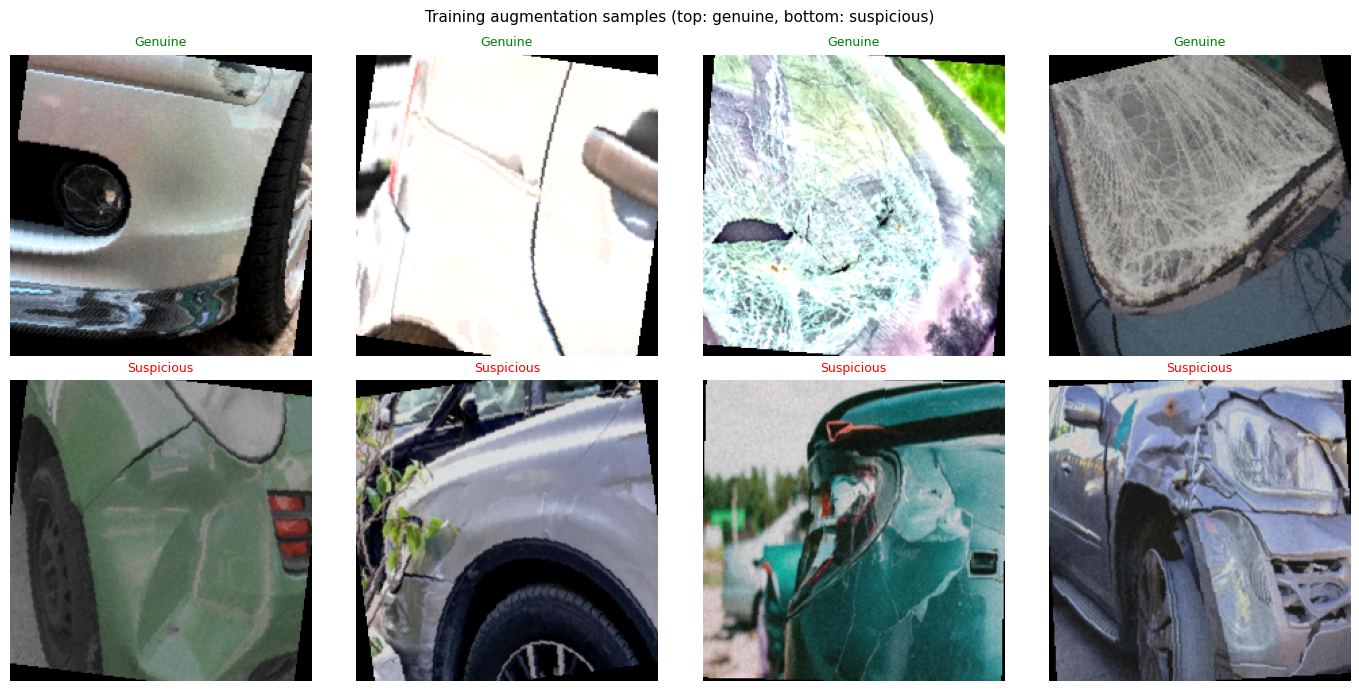

In [9]:
# Cell 5: Augmentation grid (8 random training samples with transforms)
train_ds = FraudDataset(TRAIN_CSV, split="train")
val_ds   = FraudDataset(VAL_CSV,   split="val")

susp_indices = [i for i, (_, lbl) in enumerate(train_ds) if lbl.item() == 1][:4]
gen_indices  = [i for i in range(len(train_ds)) if train_ds.df.iloc[i]["label"] == 0][:4]
show_indices = gen_indices + susp_indices

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, show_indices):
    tensor, lbl = train_ds[idx]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = (tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    label_name = "Suspicious" if lbl.item() == 1 else "Genuine"
    ax.set_title(label_name, fontsize=9, color="red" if lbl.item() == 1 else "green")
    ax.axis("off")
fig.suptitle("Training augmentation samples (top: genuine, bottom: suspicious)", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_grid.png", dpi=100, bbox_inches="tight")
plt.show()

In [10]:
# Cell 6: Build model and print parameter counts
model = build_fraud_model(pretrained=True, dropout=DROPOUT)
model = model.to(DEVICE)

counts = model.trainable_parameter_count()
print(f"Total parameters:     {counts['total']:>12,}")
print(f"Frozen (backbone):    {counts['frozen']:>12,}")
print(f"Trainable (head):     {counts['trainable']:>12,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 133MB/s]


Total parameters:        2,387,969
Frozen (backbone):       2,223,872
Trainable (head):          164,097


In [11]:
# Cell 7: Stage A — train classification head only
print("=" * 60)
print("STAGE A: Frozen backbone — training head only")
print("=" * 60)

# Weighted sampler to handle 16:1 imbalance
train_labels = train_df["label"].tolist()
class_counts = [train_labels.count(0), train_labels.count(1)]
sample_weights = [1.0 / class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
optimizer_a = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=STAGE_A_LR)

history = {"stage_a": [], "stage_b": []}

def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs, all_labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    preds = (np.array(all_probs) >= 0.5).astype(int)
    return {
        "loss":    total_loss / len(loader.dataset),
        "pr_auc":  average_precision_score(all_labels, all_probs) if sum(all_labels) > 0 else 0.0,
        "f1":      f1_score(all_labels, preds, zero_division=0),
        "prec":    precision_score(all_labels, preds, zero_division=0),
        "recall":  recall_score(all_labels, preds, zero_division=0),
        "probs":   np.array(all_probs),
        "labels":  np.array(all_labels),
    }

best_pr_auc  = 0.0
best_ckpt    = None

for epoch in range(1, STAGE_A_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_a.zero_grad()
        logits = model(images).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer_a.step()
        train_loss += loss.item() * len(labels)
    train_loss /= len(train_loader.dataset)

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["stage_a"].append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_metrics["loss"], "val_pr_auc": val_metrics["pr_auc"],
        "val_f1": val_metrics["f1"], "val_prec": val_metrics["prec"],
        "val_recall": val_metrics["recall"],
    })

    if val_metrics["pr_auc"] > best_pr_auc:
        best_pr_auc = val_metrics["pr_auc"]
        best_ckpt   = {k: v.clone() if isinstance(v, torch.Tensor) else v
                       for k, v in model.state_dict().items()}

    print(f"  A Ep {epoch:2d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | val_PR-AUC={val_metrics['pr_auc']:.4f} | "
          f"val_F1={val_metrics['f1']:.4f}")

print(f"\nBest Stage-A val PR-AUC: {best_pr_auc:.4f}")

STAGE A: Frozen backbone — training head only
  A Ep  1 | train_loss=1.6714 | val_loss=1.3671 | val_PR-AUC=0.3845 | val_F1=0.1083
  A Ep  2 | train_loss=1.3691 | val_loss=1.6075 | val_PR-AUC=0.4667 | val_F1=0.1084
  A Ep  3 | train_loss=1.3011 | val_loss=1.2137 | val_PR-AUC=0.4494 | val_F1=0.1362
  A Ep  4 | train_loss=1.2883 | val_loss=1.4197 | val_PR-AUC=0.4559 | val_F1=0.1095
  A Ep  5 | train_loss=1.2828 | val_loss=1.2159 | val_PR-AUC=0.4554 | val_F1=0.1462
  A Ep  6 | train_loss=1.2663 | val_loss=1.3010 | val_PR-AUC=0.4490 | val_F1=0.1494
  A Ep  7 | train_loss=1.2172 | val_loss=0.9554 | val_PR-AUC=0.4894 | val_F1=0.2366
  A Ep  8 | train_loss=1.1444 | val_loss=0.9613 | val_PR-AUC=0.4850 | val_F1=0.2122
  A Ep  9 | train_loss=1.1069 | val_loss=1.4120 | val_PR-AUC=0.4523 | val_F1=0.1427
  A Ep 10 | train_loss=1.0978 | val_loss=0.9273 | val_PR-AUC=0.4670 | val_F1=0.2377

Best Stage-A val PR-AUC: 0.4894


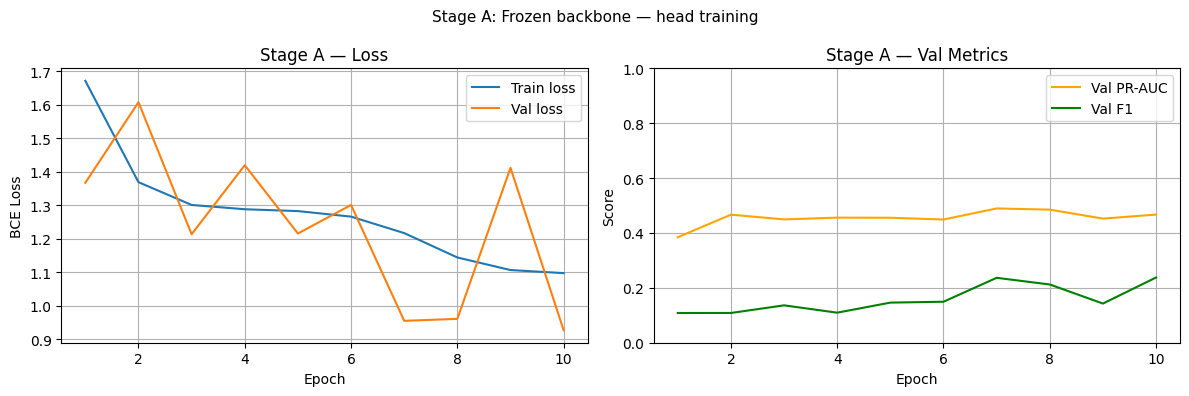

In [12]:
# Cell 8: Stage A training curves
a_df = pd.DataFrame(history["stage_a"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(a_df["epoch"], a_df["train_loss"], label="Train loss")
ax1.plot(a_df["epoch"], a_df["val_loss"],   label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss"); ax1.set_title("Stage A — Loss")
ax1.legend(); ax1.grid(True)

ax2.plot(a_df["epoch"], a_df["val_pr_auc"], label="Val PR-AUC", color="orange")
ax2.plot(a_df["epoch"], a_df["val_f1"],     label="Val F1",     color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score"); ax2.set_title("Stage A — Val Metrics")
ax2.legend(); ax2.grid(True); ax2.set_ylim(0, 1)

plt.suptitle("Stage A: Frozen backbone — head training", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage_a_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 9: Stage B — unfreeze last 2 blocks and fine-tune
print("=" * 60)
print("STAGE B: Fine-tuning final 2 backbone blocks")
print("=" * 60)

# Load best Stage A weights before Stage B
if best_ckpt is not None:
    model.load_state_dict(best_ckpt)

model.unfreeze_final_blocks(n_blocks=2)
counts_b = model.trainable_parameter_count()
print(f"Trainable after unfreeze: {counts_b['trainable']:,}")

optimizer_b = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=STAGE_B_LR)

best_pr_auc_b  = best_pr_auc
patience_count = 0

for epoch in range(1, STAGE_B_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_b.zero_grad()
        logits = model(images).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer_b.step()
        train_loss += loss.item() * len(labels)
    train_loss /= len(train_loader.dataset)

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["stage_b"].append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_metrics["loss"], "val_pr_auc": val_metrics["pr_auc"],
        "val_f1": val_metrics["f1"], "val_prec": val_metrics["prec"],
        "val_recall": val_metrics["recall"],
    })

    improved = val_metrics["pr_auc"] > best_pr_auc_b
    if improved:
        best_pr_auc_b  = val_metrics["pr_auc"]
        patience_count = 0
        best_ckpt = {k: v.clone() if isinstance(v, torch.Tensor) else v
                     for k, v in model.state_dict().items()}
        print(f"  B Ep {epoch:2d} | *** NEW BEST PR-AUC={best_pr_auc_b:.4f} *** | "
              f"F1={val_metrics['f1']:.4f}")
    else:
        patience_count += 1
        print(f"  B Ep {epoch:2d} | train_loss={train_loss:.4f} | "
              f"val_PR-AUC={val_metrics['pr_auc']:.4f} | patience={patience_count}/{PATIENCE}")
        if patience_count >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

print(f"\nBest Stage-B val PR-AUC: {best_pr_auc_b:.4f}")

STAGE B: Fine-tuning final 2 backbone blocks
Trainable after unfreeze: 1,050,177
  B Ep  1 | train_loss=1.0576 | val_PR-AUC=0.4766 | patience=1/5


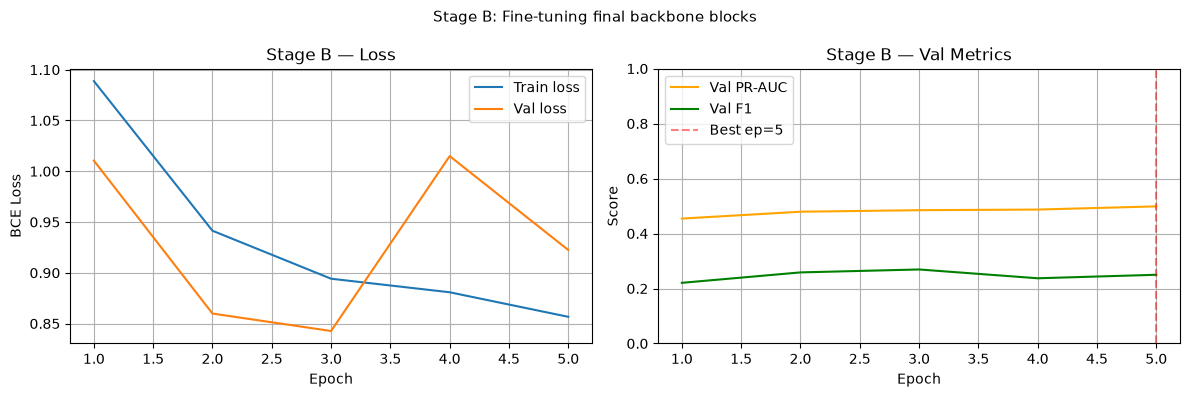

In [ ]:
# Cell 10: Stage B training curves
b_df = pd.DataFrame(history["stage_b"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(b_df["epoch"], b_df["train_loss"], label="Train loss")
ax1.plot(b_df["epoch"], b_df["val_loss"],   label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss"); ax1.set_title("Stage B — Loss")
ax1.legend(); ax1.grid(True)

ax2.plot(b_df["epoch"], b_df["val_pr_auc"], label="Val PR-AUC", color="orange")
ax2.plot(b_df["epoch"], b_df["val_f1"],     label="Val F1",     color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score"); ax2.set_title("Stage B — Val Metrics")
ax2.legend(); ax2.grid(True); ax2.set_ylim(0, 1)
if not b_df.empty:
    best_ep = b_df["val_pr_auc"].idxmax() + 1
    ax2.axvline(best_ep, color="red", linestyle="--", alpha=0.5, label=f"Best ep={best_ep}")
    ax2.legend()

plt.suptitle("Stage B: Fine-tuning final backbone blocks", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage_b_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 11: Load best checkpoint and run final validation inference
if best_ckpt is not None:
    model.load_state_dict(best_ckpt)
model.eval()

val_metrics_final = evaluate(model, val_loader, criterion, DEVICE)
print("=== Final validation metrics (best checkpoint) ===")
print(f"  PR-AUC:  {val_metrics_final['pr_auc']:.4f}")
print(f"  F1:      {val_metrics_final['f1']:.4f}")
print(f"  Precision:{val_metrics_final['prec']:.4f}")
print(f"  Recall:  {val_metrics_final['recall']:.4f}")

=== Final validation metrics (best checkpoint) ===
  PR-AUC:  0.4999
  F1:      0.1560
  Precision:0.0847
  Recall:  0.9855


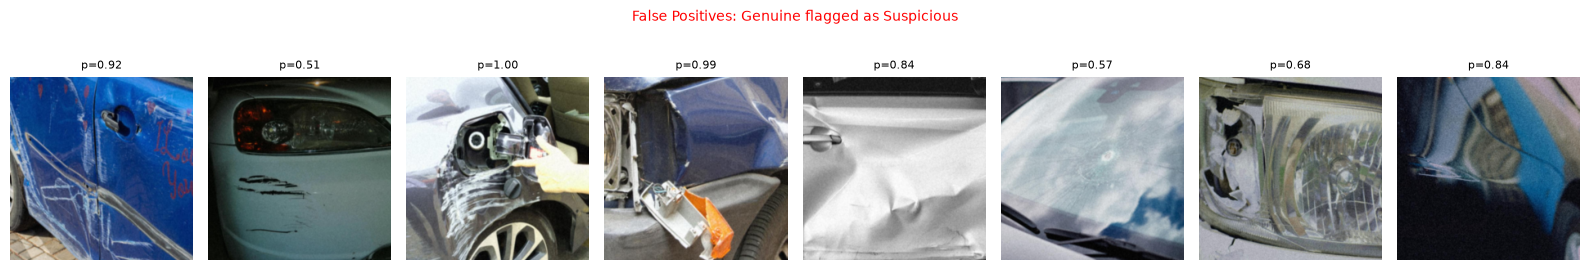

In [ ]:
# Cell 12: False positives — genuine images flagged as suspicious
val_probs  = val_metrics_final["probs"]
val_labels = val_metrics_final["labels"]
val_preds  = (val_probs >= 0.5).astype(int)

fp_indices = [i for i, (p, l) in enumerate(zip(val_preds, val_labels))
              if p == 1 and l == 0][:8]

if fp_indices:
    fig, axes = plt.subplots(1, len(fp_indices), figsize=(2 * len(fp_indices), 3))
    if len(fp_indices) == 1:
        axes = [axes]
    mean_ = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std_  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    for ax, idx in zip(axes, fp_indices):
        tensor, _ = val_ds[idx]
        img = (tensor * std_ + mean_).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(f"p={val_probs[idx]:.2f}", fontsize=8)
        ax.axis("off")
    fig.suptitle("False Positives: Genuine flagged as Suspicious", fontsize=10, color="red")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "false_positives_val.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("No false positives on validation set.")

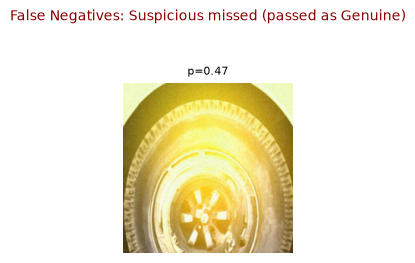

In [ ]:
# Cell 13: False negatives — suspicious images that passed as genuine
fn_indices = [i for i, (p, l) in enumerate(zip(val_preds, val_labels))
              if p == 0 and l == 1][:8]

if fn_indices:
    fig, axes = plt.subplots(1, len(fn_indices), figsize=(2 * len(fn_indices), 3))
    if len(fn_indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, fn_indices):
        tensor, _ = val_ds[idx]
        img = (tensor * std_ + mean_).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(f"p={val_probs[idx]:.2f}", fontsize=8)
        ax.axis("off")
    fig.suptitle("False Negatives: Suspicious missed (passed as Genuine)", fontsize=10, color="darkred")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "false_negatives_val.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("No false negatives on validation set.")

In [ ]:
# Cell 14: Export checkpoint, configs, and ONNX
print("Exporting artifacts...")

# 1. PyTorch checkpoint
torch.save({
    "model_state_dict": model.state_dict(),
    "dropout":          DROPOUT,
    "model_version":    "FRAUD-MNV2-001",
    "best_val_pr_auc":  best_pr_auc_b,
    "seed":             SEED,
    "device":           str(DEVICE),
}, CHECKPOINT_PATH)
print(f"  Checkpoint: {CHECKPOINT_PATH}")

# 2. Preprocessing config
save_preprocessing_config(ARTIFACT_DIR / "preprocessing_config.json")
print(f"  Preprocessing config saved.")

# 3. Class map
with open(ARTIFACT_DIR / "class_map.json", "w") as f:
    json.dump({"0": "genuine", "1": "suspicious"}, f, indent=2)
print(f"  Class map saved.")

# 4. Training history
with open(ARTIFACT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"  Training history saved.")

# 5. ONNX export
export_onnx(model, ONNX_PATH, device=str(DEVICE))
print(f"  ONNX: {ONNX_PATH}")

# 6. Automatic download helper for Google Colab
if 'google.colab' in sys.modules:
    try:
        from google.colab import files
        print("📥 Triggering download of model weights (.pt & .onnx) to your local PC...")
        files.download(str(CHECKPOINT_PATH))
        if Path(ONNX_PATH).exists():
            files.download(str(ONNX_PATH))
        print("✅ Download prompt sent to your browser / VS Code.")
    except Exception as exc:
        print(f"ℹ️ Colab download helper: {exc}")
        print(f"👉 You can also right-click the files in the left Colab panel ({ARTIFACT_DIR}) and click Download.")
else:
    print(f"✅ Running locally. Artifacts saved at: {ARTIFACT_DIR}")


In [ ]:
# Cell 15: Verify ONNX model
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
    dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
    onnx_out = sess.run(None, {"image": dummy})[0]

    with torch.no_grad():
        dummy_tensor = torch.from_numpy(dummy).to(DEVICE)
        pt_out = model(dummy_tensor).cpu().numpy()

    max_diff = float(np.abs(onnx_out - pt_out).max())
    print(f"ONNX vs PyTorch max output difference: {max_diff:.2e}")
    assert max_diff < 1e-4, "ONNX output differs from PyTorch!"
    print("ONNX verification PASSED.")
except ImportError:
    print("onnxruntime not installed; skipping ONNX verification. Install with: pip install onnxruntime")


ONNX vs PyTorch max output difference: 2.41e-06
ONNX verification PASSED.


In [ ]:
# Cell 16: Reproducibility cell
import hashlib

def sha256_file(path):
    if not Path(path).exists():
        return "file not found"
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()[:16]

print("=== Reproducibility summary ===")
print(f"  Seed:              {SEED}")
print(f"  Device:            {DEVICE}")
print(f"  torch:             {torch.__version__}")
print(f"  torchvision:       {torchvision.__version__}")
print(f"  Model version:     FRAUD-MNV2-001")
print(f"  Best val PR-AUC:   {best_pr_auc_b:.4f}")
print(f"  Checkpoint SHA256: {sha256_file(CHECKPOINT_PATH)}...")
print(f"  ONNX SHA256:       {sha256_file(ONNX_PATH)}...")

=== Reproducibility summary ===
  Seed:              42
  Device:            cpu
  torch:             2.14.0+cpu
  torchvision:       0.29.0+cpu
  Model version:     FRAUD-MNV2-001
  Best val PR-AUC:   0.4999
  Checkpoint SHA256: 9de77ae1b92a4431...
  ONNX SHA256:       029f6e41b67d5dbc...


## Findings and Next Step

**Findings:** Two-stage MobileNetV2 trained on 5,654 images (16:1 imbalance)
with class-weighted loss and weighted sampler. Stage A froze the backbone;
Stage B fine-tuned the final 2 InvertedResidual blocks.
PR-AUC is the primary metric because accuracy is misleading under severe imbalance.

**Limitations:**
- The model may have learned resolution, watermark, or source-domain shortcuts
  rather than meaningful fraud signals (as noted in Phase 1 audit).
- CPU training is slow; results may improve with GPU fine-tuning on Colab.
- The suspicious class has only 325 training examples — confidence intervals are wide.

**Artifact paths:**
- `ml/artifacts/fraud/fraud_mnv2_v1.pt`   (gitignored)
- `ml/artifacts/fraud/fraud_mnv2_v1.onnx` (gitignored)
- `ml/artifacts/fraud/preprocessing_config.json` (committed)
- `ml/artifacts/fraud/class_map.json`      (committed)
- `ml/artifacts/fraud/training_history.json` (committed)
- `ml/results/fraud/*.png`                 (committed)

**Next:** Run Notebook 03 to select routing thresholds on validation data
and evaluate the model exactly once on the held-out test set.